### Notebook for test and demonstration of use of Ballistic Tables in an ICBM scenario.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np

import matplotlib.pyplot as plt
import plotly.graph_objects as go
import seaborn as sns
from mad.configs import titan1_stages
from mad.configs import B53_warhead
from mad.configs import EARTH_SETTINGS
from mad.objs import Planet, PlanetConfig
from mad.objs import RocketConfig, RocketStage, RocketStageConfig, Rocket, RVConfig
from mad.guidances import TabulatedBallistic, NoGuidance, NoGuidanceNoThrust
from mad.simulation import Simulation
from mad.utils.logger import SourceLogger
from mad.utils.plotters import plot_2D_planet_with_points
from mad.utils.objs_helpers import random_point_at_planet_surface, point_at_planet_surface_distance

logger = SourceLogger()

In [3]:
# As usual, we start by defining our planet.
EARTH_SETTINGS["position"] = [0.0, 0.0]

launchsite_target_distance_km = 12_000
earth = Planet(PlanetConfig(**EARTH_SETTINGS))
launchpad = random_point_at_planet_surface(earth, name="Launchpad", altitude=10, dims=2)
target = point_at_planet_surface_distance(earth, launchpad, distance_km=launchsite_target_distance_km, name="Target", dims=2)

earth

Planet Earth at [0. 0. 0.]
Mass 5.97e+24 kg, Radius 6371.0 km.
Gravity at surface: 9.82 m/s^2
Orbital velocity: 7909.55 m/s
Escape velocity: 11185.79 m/s

In [4]:
# Rockets are defined by a list of stages, a guidance system, and a list of payloads. 
# The Titan 1 rocket has two stages, and we will use a tabulated ballistic guidance system 
# to guide the rocket to the target. 
# The payload is a B53 warhead, released unpowered (NoGuidanceNoThrust) so it follows a pure
# ballistic coast matching the tabulated trajectories.
rocket_stages = [RocketStage(RocketStageConfig(**stage_cfg)) for stage_cfg in titan1_stages]
# The ballistic table is adapted to the target distance and the warhead.
# It will release the warhead at the right time / range to hit the target.
rocket_guidance = TabulatedBallistic(planet=earth, 
                                     target=target, 
                                     ballistic_table_name="B53_warhead_full_range")

warhead_guidance = NoGuidanceNoThrust(planet=earth, target=target)
payload_cfg = RVConfig(**B53_warhead, guidance=warhead_guidance)

rocket_cfg = RocketConfig(stages=rocket_stages, 
                          guidance=rocket_guidance, 
                          payloads=[payload_cfg],
                          name="Titan 1",
                          )
# We put the rocket on the launchpad, and we are ready to simulate its flight.
titan = Rocket(position=launchpad.position.copy(), config=rocket_cfg)

titan

16:54:20 | WARNING  | I/O          | Ballistic table 'B53_warhead_full_range' has 11999 missing entrie(s); queries interpolated near them will return NaN.


Rocket Titan 1, active.
Stages: Stage1, Stage2.
Available deltaV: 11818.37 m/s.
Guidance: TabulatedBallistic.
Payloads: B53Warhead.

We will use a Simulation class to run the whole simulation and collect the results.

It allows to get a granular view of the events through the logger.

In [5]:
dt = 0.2
max_time = 4_000.

sim = Simulation(max_time=max_time, dt=dt)
sim.run(
    planet=earth,
    moving_objs=[titan],
)

# Recorded states of the simulation are stored in a pandas dataframe.
df = sim.results


16:54:22 | INFO     | Simulation   | 0.00s - Starting simulation.
16:54:22 | INFO     | Rocket       | 108.40s - Stage1 ran out of propellant at 108.40.
16:54:22 | INFO     | Rocket       | 108.40s - Titan 1 - Stage1 separated at 108.40.
16:54:22 | INFO     | Rocket       | 108.40s - Titan 1 - Stage2 ignited at 108.40.
16:54:22 | INFO     | Simulation   | 108.40s - New objects spawned this step: ['Stage1']
16:54:23 | INFO     | Rocket       | 316.80s - Titan 1 released payload B53Warhead at 316.80.
16:54:23 | INFO     | Rocket       | 316.80s - Titan 1 has released all payloads at 316.80. Stages deactivated.
16:54:23 | INFO     | Rocket       | 316.80s - Titan 1 - Stage2 separated at 316.80.
16:54:23 | INFO     | Rocket       | 316.80s - Titan 1 inactivated at 316.80.
16:54:23 | INFO     | Simulation   | 316.80s - New objects spawned this step: ['B53Warhead', 'Stage2']
16:54:23 | INFO     | Projectile   | 574.60s - Stage1 landed on the ground!
16:54:24 | INFO     | Rocket       | 2999.

In [6]:
df["altitude_km"] = df["position"].apply(lambda pos: (np.linalg.norm(pos) - earth.radius) / 1e3)
df["energy_kJ"] = df["speed"].apply(lambda speed: 0.5 * speed**2 / 1e3)
df["gamma_deg"] = df["gamma"].apply(lambda g: np.degrees(g) if g is not None else None)
df = df.sort_values(by=["name", "time"])

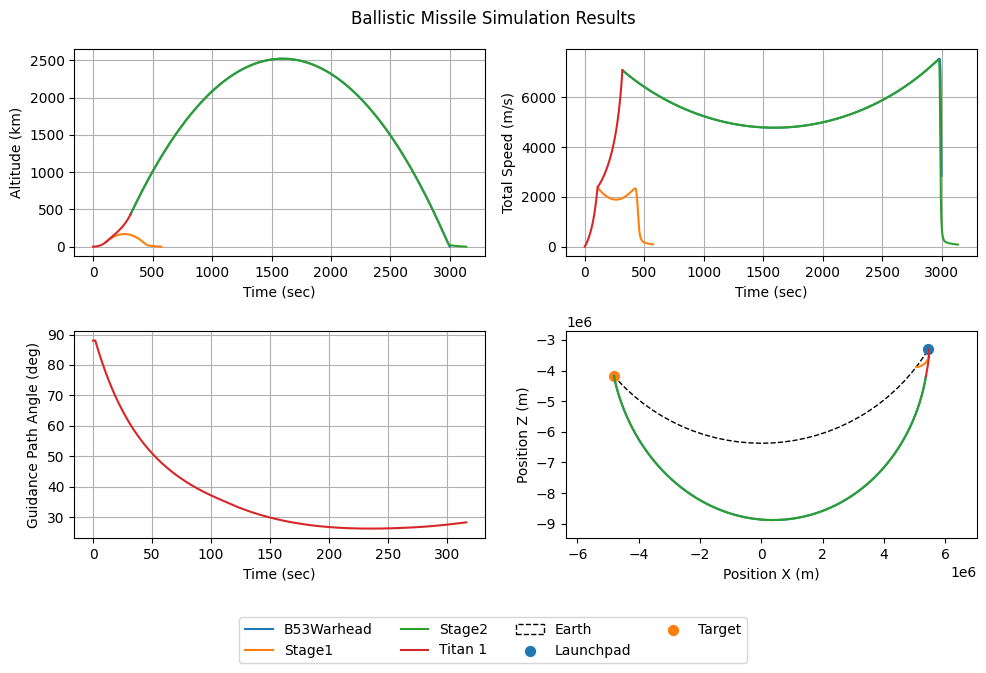

In [7]:
fig, ax = plt.subplots(ncols=2, nrows=2, figsize=(10, 6))
ax = ax.ravel()

sns.lineplot(data=df, x="time", y="altitude_km", hue="name", ax=ax[0])
sns.lineplot(data=df, x="time", y="speed", hue="name", ax=ax[1])
sns.lineplot(data=df, x="time", y="gamma_deg", hue="name", ax=ax[2])
sns.lineplot(data=df, x="posx", y="posz", hue="name", ax=ax[3], sort=False, errorbar=None)

ax[0].set_xlabel("Time (sec)")
ax[0].set_ylabel("Altitude (km)")

ax[1].set_xlabel("Time (sec)")
ax[1].set_ylabel("Total Speed (m/s)")

ax[2].set_xlabel("Time (sec)")
ax[2].set_ylabel("Guidance Path Angle (deg)")

plot_2D_planet_with_points(earth, points = [launchpad, target], ax=ax[3], display="arc")
ax[3].set_xlabel("Position X (m)")
ax[3].set_ylabel("Position Z (m)")
ax[3].set_aspect("equal", adjustable="datalim")

for a in ax:
    a.grid()
    a.legend()
    handles, labels = a.get_legend_handles_labels()
    a.legend().remove()

fig.suptitle("Ballistic Missile Simulation Results")
fig.legend(handles, labels, loc="lower center", ncol=4, bbox_to_anchor=(0.5, -0.12))
fig.tight_layout(pad=1.2)

In [12]:

u, v = np.mgrid[0:2*np.pi:60j, 0:np.pi:30j]
R = earth.radius

fig = go.Figure()

# Planet sphere
fig.add_trace(go.Surface(
    x=R * np.cos(u) * np.sin(v),
    y=R * np.sin(u) * np.sin(v),
    z=R * np.cos(v),
    colorscale="Blues", showscale=False, opacity=0.6,
    name="Earth", hoverinfo="skip",
))

# One trace per object, coloured like seaborn hue="name"
colors = [
    "#636EFA", "#EF553B", "#00CC96", "#AB63FA", "#FFA15A",
    "#19D3F3", "#FF6692", "#B6E880", "#FF97FF", "#FECB52",
]
for i, (name, group) in enumerate(df.groupby("name", sort=False)):
    pos = np.stack(group.sort_values("time")["position"].values)
    fig.add_trace(go.Scatter3d(
        x=pos[:, 0], y=pos[:, 1], z=pos[:, 2],
        mode="lines",
        line=dict(width=4, color=colors[i % len(colors)]),
        name=name,
    ))

fig.update_layout(
    scene=dict(aspectmode="data"),
    legend=dict(x=0, y=1),
    margin=dict(l=0, r=0, t=30, b=0),
)
fig.show()
